In [17]:
import h5py
import numpy as np
import gvar as gv
import math
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import inspect
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom

def ReA12B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return -a * gv.exp(-f * eta) / denom

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # 1. Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            # Read the dataset back into a numpy array
            fitted_params[key] = param_group[key][:]
            
        # 2. Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
        
    return fitted_params, chi2_dof_list

def plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL, num_points=200):
    print(f"Simultaneous Fit (ReA2B, ImA2B, & ReA12B) : PL={PL}, b_min>=3, eta in [6, 10] ---")
    print("\n--- Fit Functions ---")
    print(inspect.getsource(ReA2B))
    print(inspect.getsource(ImA2B))
    print(inspect.getsource(ReA12B))
    print("---------------------\n")
    track_param_names = [
        'k1_re', 'k2_re', 'f', 'a_re', 'c_re', 'd_re', 'j_re',
        'a_im', 'c_im', 'd_im', 'j_im', 
        'a_reA12B', 'c_reA12B', 'd_reA12B', 'j_reA12B'
    ]
    print("\n--- Final Extracted Parameters ---")
    for key in track_param_names:
        mean_val, err_val = Jackknife(fitted_params[key])
        print(f"{key:>10} = {fmt_err(mean_val, err_val)}")
        
    mean_chi2, err_chi2 = Jackknife(chi2_dof_list)
    print(f"\n chi^2/dof : {fmt_err(mean_chi2, err_chi2)}\n")
    
    # 1. Setup x-axis (avoid exactly 0 to prevent division by zero in Bessel/powers)
    x_vals = np.linspace(-1, 1, num_points)
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN*(197*0.001/lata)
    
    # 2. Extract parameters as NumPy arrays
    a_re = np.array(fitted_params['a_re'])
    c_re = np.array(fitted_params['c_re']) / (PL**2)
    d_re = 1.0 + np.array(fitted_params['d_re']) * b2  
    j_re = np.array(fitted_params['j_re'])

    a_im = np.array(fitted_params['a_im']) / PL
    c_im = np.array(fitted_params['c_im']) / (PL**2)
    d_im = 1.0 + np.array(fitted_params['d_im']) * b2
    j_im = np.array(fitted_params['j_im'])

    a_reA12B = -np.array(fitted_params['a_reA12B'])
    c_reA12B = np.array(fitted_params['c_reA12B']) / (PL**2)
    d_reA12B = 1.0 + np.array(fitted_params['d_reA12B']) * b2  
    j_reA12B = np.array(fitted_params['j_reA12B'])

    # Prepare lists to store the jackknife results for plotting
    re_mean, re_err = [], []
    reA12B_mean, reA12B_err = [], []
    im_mean, im_err = [], []
    full_mean, full_err = [], []
    SiverseShift_mean, SiverseShift_err = [], []
    xSiverseShift_mean, xSiverseShift_err = [], []

    print("Evaluating Fourier transforms and applying Jackknife...")
    
    # 3. Loop over each x value and apply your Jackknife function
    for x in x_vals:
        abs_x = np.abs(x)

        # --- Evaluate Real Part for all ~2900 samples at this x ---
        cd_R = c_re / d_re
        term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
        term2_R = abs_x**(-0.5 + j_re)
        bessel_R = kv(0.5 - j_re, abs_x / np.sqrt(cd_R))
        
        re_evals_at_x = term1_R * term2_R * bessel_R
        
        # Apply your Jackknife function
        m_re, e_re = Jackknife(re_evals_at_x)
        re_mean.append(m_re)
        re_err.append(e_re)

        # --- Evaluate Imaginary Part for all ~2900 samples at this x ---
        cd_I = c_im / d_im
        term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
        term2_I = x * abs_x**(-1.5 + j_im)
        bessel_I = kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)
        
        im_evals_at_x = term1_I * term2_I * bessel_I
        
        # Apply your Jackknife function
        m_im, e_im = Jackknife(im_evals_at_x)
        im_mean.append(m_im)
        im_err.append(e_im)

        m_full, e_full = Jackknife(2*(re_evals_at_x-im_evals_at_x))
        full_mean.append(m_full)
        full_err.append(e_full)

        ####################
        cd_RA12B = c_reA12B / d_reA12B
        term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
        term2_RA12B = abs_x**(-0.5 + j_reA12B)
        bessel_RA12B = kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))
        
        reA12B_evals_at_x = term1_RA12B * term2_RA12B * bessel_RA12B
        
        # Apply your Jackknife function
        m_reA12B, e_reA12B = Jackknife(-2*reA12B_evals_at_x)
        reA12B_mean.append(m_reA12B)
        reA12B_err.append(e_reA12B)

        m_SiverseShift, e_SiverseShift = Jackknife((-massterm*reA12B_evals_at_x)/(re_evals_at_x-im_evals_at_x))
        SiverseShift_mean.append(m_SiverseShift)
        SiverseShift_err.append(e_SiverseShift)


        m_xSiverseShift, e_xSiverseShift = Jackknife(x*(-massterm*reA12B_evals_at_x)/(re_evals_at_x-im_evals_at_x))
        xSiverseShift_mean.append(m_xSiverseShift)
        xSiverseShift_err.append(e_xSiverseShift)

    # Convert results to arrays for easier plotting
    re_mean, re_err = np.array(re_mean), np.array(re_err)
    im_mean, im_err = np.array(im_mean), np.array(im_err)
    full_mean, full_err = np.array(full_mean), np.array(full_err)
    reA12B_mean, reA12B_err = np.array(reA12B_mean), np.array(reA12B_err)
    SiverseShift_mean, SiverseShift_err = np.array(SiverseShift_mean), np.array(SiverseShift_err)
    xSiverseShift_mean, xSiverseShift_err = np.array(xSiverseShift_mean), np.array(xSiverseShift_err)

    # 4. Plotting
    #fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(14, 8))

    # Real Plot
    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean - re_err, re_mean + re_err, color='blue', alpha=0.3, label='Jackknife Error Band')
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    #ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean - im_err, im_mean + im_err, color='red', alpha=0.3, label='Jackknife Error Band')
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    #ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)


    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean - full_err, full_mean + full_err, color='green', alpha=0.3, label='Jackknife Error Band')
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2}) = $\\tilde{{A}}_{{2B}}^{{Re}}+i(i\\tilde{{A}}_{{2B}}^{{Im}})$')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{f}}_{{1}}^{{(0)}}$')
    #ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.6)

    ax4.plot(x_vals, reA12B_mean, color='blue')
    ax4.fill_between(x_vals, reA12B_mean - reA12B_err, reA12B_mean + reA12B_err, color='blue', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($P_L$={PL}, $b^2$={b2})')
    ax4.set_xlabel('$x$')
    ax4.set_ylabel('$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')
    ax4.grid(True, linestyle='--', alpha=0.6)
    # Create mask for x values from 0 to 1
    mask = x_vals >= 0

    # Sivers Shift Plot (0 to 1)
    ax5.plot(x_vals[mask], SiverseShift_mean[mask], color='blue')
    ax5.fill_between(x_vals[mask], SiverseShift_mean[mask] - SiverseShift_err[mask], 
                     SiverseShift_mean[mask] + SiverseShift_err[mask], color='blue', alpha=0.3)
    ax5.set_title(f'$\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={PL}, $b^2$={b2})')
    ax5.set_xlabel('$x$')
    ax5.set_ylabel('$\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')
    ax5.grid(True, linestyle='--', alpha=0.6)

    # x*Sivers Shift Plot (0 to 1)
    ax6.plot(x_vals[mask], xSiverseShift_mean[mask], color='blue')
    ax6.fill_between(x_vals[mask], xSiverseShift_mean[mask] - xSiverseShift_err[mask], 
                     xSiverseShift_mean[mask] + xSiverseShift_err[mask], color='blue', alpha=0.3)
    ax6.set_title(f'$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV) ($P_L$={PL}, $b^2$={b2})')
    ax6.set_xlabel('$x$')
    ax6.set_ylabel('$x\\langle k_{{y}} \\rangle_{{TU}}$(GeV)')
    ax6.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = f"SimulFitCovMatrix-A2B-FT-{param_keys_str}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

    return 


Simultaneous Fit (ReA2B, ImA2B, & ReA12B) : PL=-1, b_min>=3, eta in [6, 10] ---

--- Fit Functions ---
def ReA2B(eta, bL, bT, a, c, d, f, k1, k2, j):
    denom = (1 + (d + c * (1 - k1/eta - k2/eta**2)) * bL**2 + d * bT**2)**j
    return a * gv.exp(-f * eta) / denom

def ImA2B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return a * bL * gv.exp(-f * eta) / denom

def ReA12B(eta, bL, bT, a, c, d, f, j):
    denom = (1 + (d + c) * bL**2 + d * bT**2)**j
    return -a * gv.exp(-f * eta) / denom

---------------------


--- Final Extracted Parameters ---
     k1_re = 12.288(23)
     k2_re = -36.1965(45)
         f = 0.4702(46)
      a_re = 3.863(11)
      c_re = 0.336(40)
      d_re = 0.1630(74)
      j_re = 1.627(25)
      a_im = 0.267(13)
      c_im = 0.2253(69)
      d_im = 0.2205(66)
      j_im = 1.108(21)
  a_reA12B = 0.658(22)
  c_reA12B = 0.0773(46)
  d_reA12B = 0.0747(43)
  j_reA12B = 2.0054(90)

 chi^2/dof : 1.85(10)

Evaluating Fourier transforms

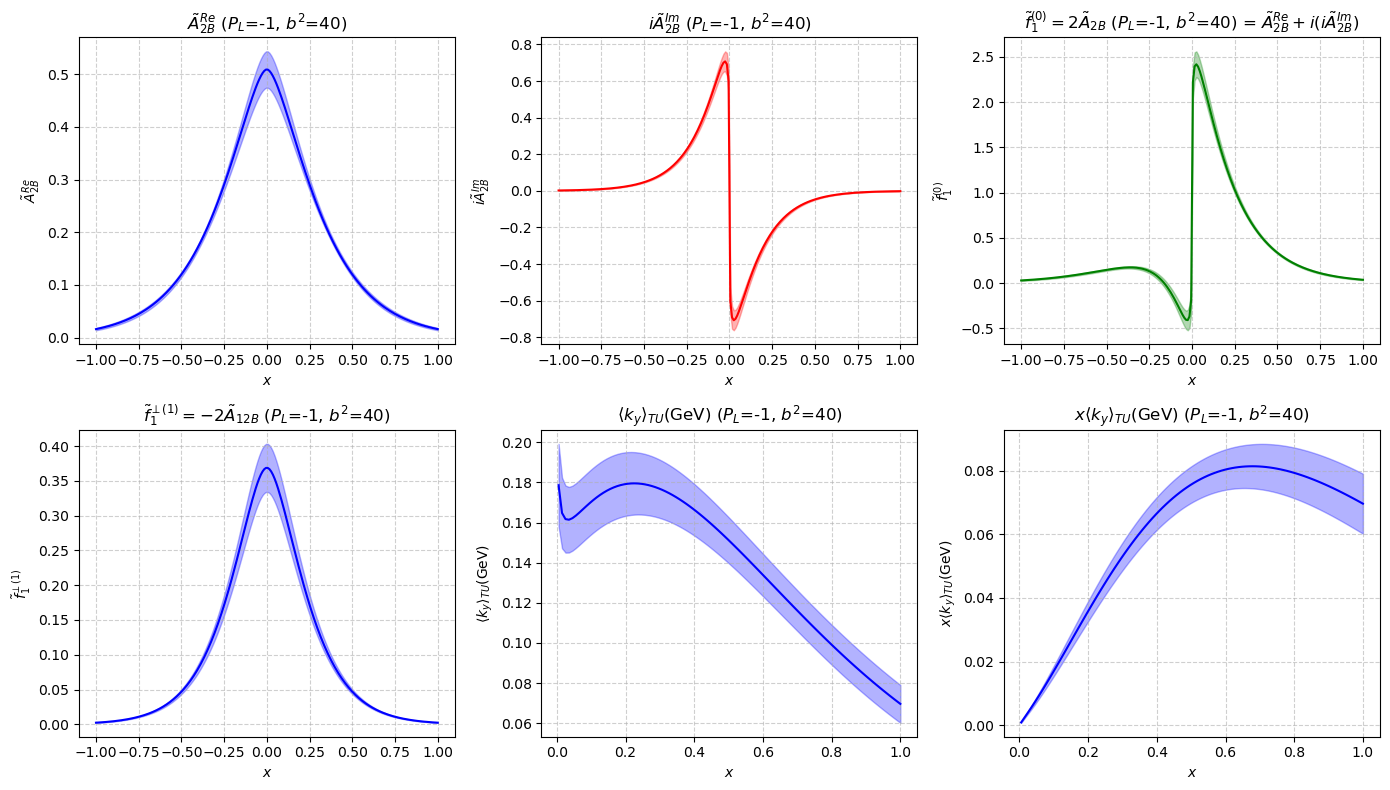

In [18]:
b2 = 40
PL = -1
fitted_params, chi2_dof_list = load_params_from_h5(f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin3_eta610_PL{PL}.h5")
plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL)
